# Field Trip 1 Data Plotting 

The code below is designed to teach you how to go about relativley simple data plotting using Python.  Most of the key snippets of code are included below.  Your task is to fill in the blanks so that the code runs correctly for our 2026 data. 

Some tips: 
Be sure to check all titles and axis labels.   
In the task below, you will only need to update the sections where indicated.  

Using the processed data file you created during the last step, use the code below to plot some nice plots of our data that can be used for your next assessment task where we will need to visualise and interpret the data.

Below you wil see a new library called Seaborn.  Seaborn is a high‑level data visualization library built on Matplotlib.  It is designed for statistical graphics—relationships, distributions, categories, regression, and more and it works seamlessly with pandas DataFrames, letting you refer to columns by name.


In [1]:
! pip install seaborn

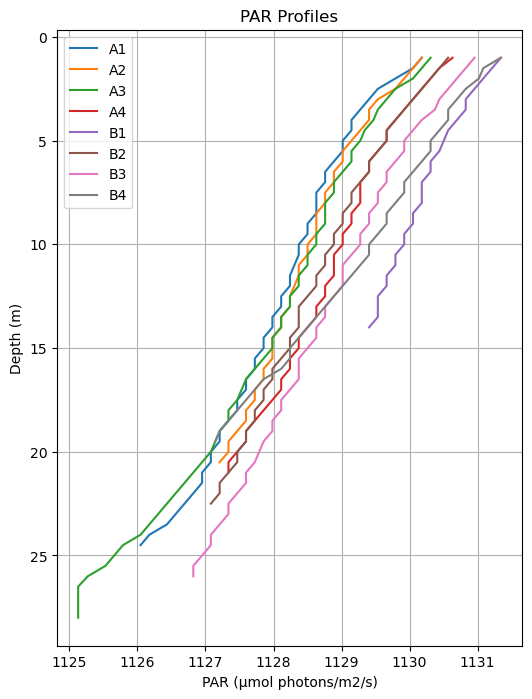

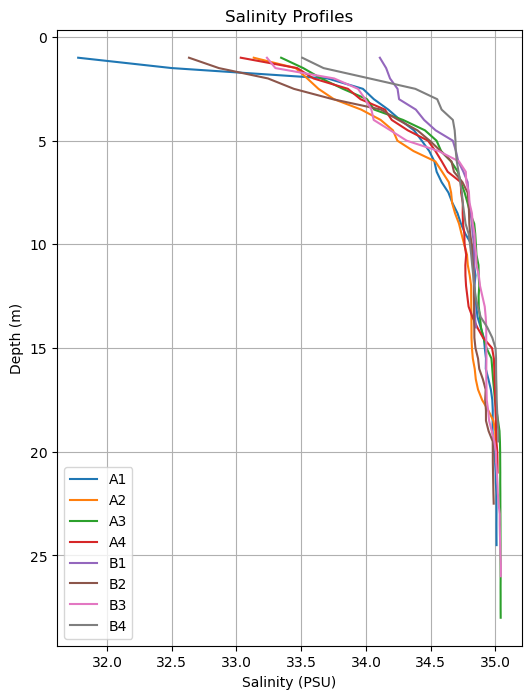

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Load the processed CTD dataset
# ------------------------------------------------------------
# The CSV file contains binned CTD profiles from multiple stations.
# Each row represents a depth bin at a specific station, with variables
# such as Temperature, Salinity, and Depth_Bin.
df = pd.read_csv("processed_ctd_profiles.csv")

# ------------------------------------------------------------
# Remove surface data (depth < 1 m)
# ------------------------------------------------------------
# Many CTD casts have noisy or unstable values right at the surface.
# Filtering out the shallowest bin helps produce cleaner profiles.
df = df[df["Depth_Bin"] >= 1.0]

# ------------------------------------------------------------
# Identify stations and assign each one a unique colour
# ------------------------------------------------------------
# 'Station' is a categorical variable indicating where each CTD cast
# was taken. We extract the unique station names and then generate
# a colour palette with one colour per station.
stations = df["Station"].unique()
colors = sns.color_palette("tab10", len(stations))

# ------------------------------------------------------------
# Plot Temperature vs Depth for all stations
# ------------------------------------------------------------
plt.figure(figsize=(6, 8))

# Loop through each station and plot its profile
for station, color in zip(stations, colors):
    # Select only the rows belonging to this station
    subset = df[df["Station"] == station]

    # Plot Temperature (x-axis) against Depth (y-axis)
    # Using a consistent colour for each station
    plt.plot(subset["PAR_photons"], subset["Depth_Bin"],
             label=station, color=color)

# In oceanography, depth increases downward, so we invert the y-axis
plt.gca().invert_yaxis()

plt.xlabel("PAR (μmol photons/m2/s)")
plt.ylabel("Depth (m)")
plt.title("PAR Profiles")
plt.legend()      # Show station names
plt.grid()        # Add gridlines for readability
plt.show()

# ------------------------------------------------------------
# Plot Salinity vs Depth for all stations
# ------------------------------------------------------------
plt.figure(figsize=(6, 8))

for station, color in zip(stations, colors):
    subset = df[df["Station"] == station]

    # Same idea as above, but now plotting Salinity
    plt.plot(subset["Salinity"], subset["Depth_Bin"],
             label=station, color=color)

plt.gca().invert_yaxis()

plt.xlabel("Salinity (PSU)")
plt.ylabel("Depth (m)")
plt.title("Salinity Profiles")
plt.legend()
plt.grid()
plt.show()

Adjust the code above to plot all the other variables to perform you first pass of QC.  Flag any data in your final data file that is clearly inaccurate.  


Great, now lets produce a simple T-S plot showing each of the stations as a new colour on a scatter plot.  

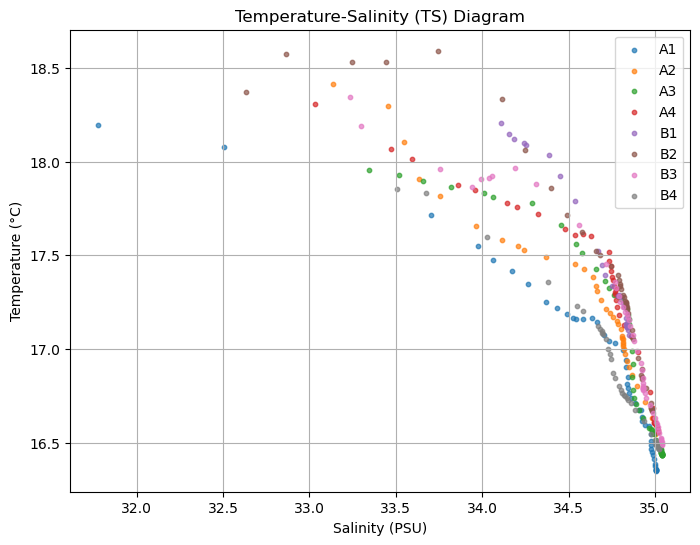

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load processed CTD data
df = pd.read_csv("processed_ctd_profiles.csv")

# Remove surface data (depth < 1 m)
df = df[df["Depth_Bin"] >= 1.0]

# Define unique stations and colors
stations = df["Station"].unique()
colors = sns.color_palette("tab10", len(stations))

# Create figure for T-S plot
plt.figure(figsize=(8, 6))

for station, color in zip(stations, colors):
    subset = df[df["Station"] == station]
    plt.scatter(subset["Salinity"], subset["Temperature"], label=station, color=color, s=10, alpha=0.7)

# Label axes
plt.xlabel("Salinity (PSU)")
plt.ylabel("Temperature (°C)")
plt.title("Temperature-Salinity (TS) Diagram")
plt.legend()
plt.grid()

# Show plot
plt.show()


Now lets produce a slightly more complicated (and useful) plot using the TEOS-10 library to calculate some advanced paramters from our data.  TEOS‑10 is the modern, internationally accepted standard for describing the thermodynamics of seawater. The Python library gsw implements these equations. It gives more accurate and physically consistent calculations than older formulas and replaces practical salinity with Absolute Salinity (SA) and in-situ temperature with Conservative Temperature (CT). 
- Absolute Salinity (SA) — accounts for regional variations in seawater composition
- Conservative Temperature (CT) — a better measure of heat content


We should use the TEOS-10 calculations where possible because your density calculations will be correct, your T-S diagrams reflect real water mass structure and it matches modern oceangraphic best practice.  


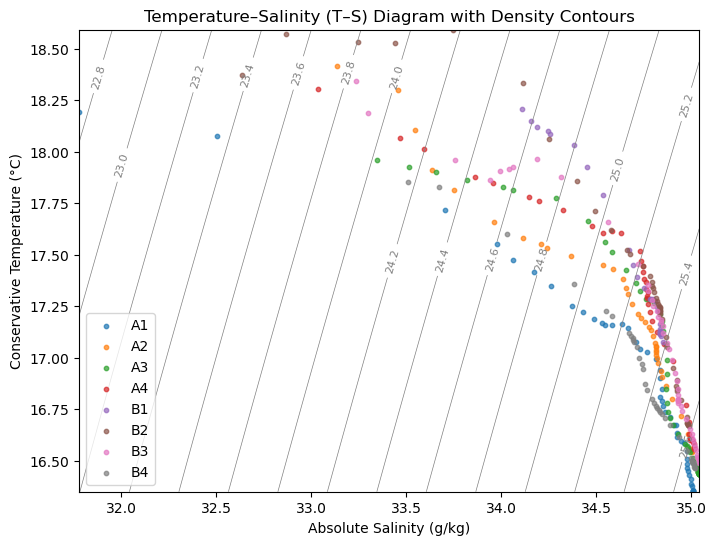

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gsw   # Gibbs SeaWater library for TEOS‑10 calculations

# ------------------------------------------------------------
# Load the processed CTD dataset
# ------------------------------------------------------------
# The CSV contains binned CTD profiles from multiple stations.
# Each row includes Salinity, Temperature, Depth_Bin, and Station.
df = pd.read_csv("processed_ctd_profiles.csv")

# ------------------------------------------------------------
# Remove surface data (depth < 1 m)
# ------------------------------------------------------------
# Surface bins can be noisy due to ship motion, bubbles, or sensor
# equilibration. Removing them produces cleaner T–S relationships.
df = df[df["Depth_Bin"] >= 1.0]

# ------------------------------------------------------------
# Convert Practical Salinity (SP) → Absolute Salinity (SA)
# Convert in‑situ Temperature (t) → Conservative Temperature (CT)
# ------------------------------------------------------------
# TEOS‑10 uses SA and CT because they are thermodynamically consistent.
# - SA accounts for spatial variations in seawater composition.
# - CT is proportional to heat content and is better for density.
#
# NOTE: You must supply approximate longitude/latitude for SA_from_SP.
df["SA"] = gsw.SA_from_SP(df["Salinity"], df["Depth_Bin"],
                          lon=147, lat=-42)  # Adjust for your region

df["CT"] = gsw.CT_from_t(df["SA"], df["Temperature"], df["Depth_Bin"])

# ------------------------------------------------------------
# Identify stations and assign colours
# ------------------------------------------------------------
# Each station will be plotted in a different colour on the T–S diagram.
stations = df["Station"].unique()
colors = sns.color_palette("tab10", len(stations))

# ------------------------------------------------------------
# Create a grid of salinity and temperature values
# to compute density contours
# ------------------------------------------------------------
# These ranges span the observed data and allow us to compute
# sigma_0 (potential density anomaly referenced to 0 dbar).
sal_range = np.linspace(df["Salinity"].min(), df["Salinity"].max(), 100)
temp_range = np.linspace(df["Temperature"].min(), df["Temperature"].max(), 100)

# Create a 2D grid of all combinations of salinity and temperature
SAL_GRID, TEMP_GRID = np.meshgrid(sal_range, temp_range)

# Convert grid values to SA and CT at the surface (pressure = 0 dbar)
SA_GRID = gsw.SA_from_SP(SAL_GRID, 0, lon=147, lat=-42)
CT_GRID = gsw.CT_from_t(SA_GRID, TEMP_GRID, 0)

# Compute sigma_0 density anomaly for each grid point
DENSITY_GRID = gsw.sigma0(SA_GRID, CT_GRID)

# ------------------------------------------------------------
# Create the T–S diagram
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))

# ------------------------------------------------------------
# Plot density contours
# ------------------------------------------------------------
# Density lines help researchers see water mass structure.
# Contours every 0.2 kg/m³ are typical for interpretation in coastal waters.
contour_levels = np.arange(np.floor(DENSITY_GRID.min()),
                           np.ceil(DENSITY_GRID.max()), 0.2)

contours = plt.contour(SAL_GRID, TEMP_GRID, DENSITY_GRID,
                       levels=contour_levels,
                       colors='gray', linewidths=0.5)

plt.clabel(contours, fmt="%.1f", fontsize=8, inline=True)

# ------------------------------------------------------------
# Plot T–S data points for each station
# ------------------------------------------------------------
for station, color in zip(stations, colors):
    subset = df[df["Station"] == station]

    # Plot Practical Salinity vs in‑situ Temperature
    # (Students will see the difference between SP/t and SA/CT)
    plt.scatter(subset["Salinity"], subset["Temperature"],
                label=station, color=color, s=10, alpha=0.7)

# ------------------------------------------------------------
# Label axes and add legend
# ------------------------------------------------------------
plt.xlabel("Absolute Salinity (g/kg)")
plt.ylabel("Conservative Temperature (°C)")
plt.title("Temperature–Salinity (T–S) Diagram with Density Contours")
plt.legend()

# Display the final figure
plt.show()